## Read in binary SpikeGadget data

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pynwb
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd

In [27]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.gyroscope import (gyroscope_data_day,
    extract_gyro_data_in_interval, extract_position_data_in_interval,
    prepare_data_for_tracking,run_trodes_tracking,translate_time,translate_time_new)

In [4]:
nwb_file_name = 'julio20230731.nwb'#'julio20230805.nwb'#'eliot20221022.nwb'
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

In [29]:
translate_time_new(np.array([1,2,1,5]),np.array([1,2,3,4,1,2,5]),np.array([1,2,3,4,5,6,7])*10**9)

new version


array([1., 2., 5., 7.])

In [24]:
#%debug

In [30]:
parent_folder = "/stelmo/shijie/recording_pilot/julio/preprocessing/"
data_day = gyroscope_data_day(nwb_file_name, parent_folder)

[2025-12-16 10:51:10,984][WARNING]: Skipped checksum for file with hash: 3dff66e2-eb07-6220-818c-94b5d5928dc0, and path: /stelmo/nwb/raw/julio20230731_.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/pynwb/behavior.py:48: UserWarning: SpatialSeries 'series_0' has data shape (42527, 6) which is not compliant with NWB 2.5 and greater. The second dimension should have length <= 3 to represent at most x, y, z.
  warnings.warn("SpatialSeries '%s' has data shape %s which is not compliant with NWB 2.5 and greater. "
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/pynwb/behavior.py:48: UserWarning: SpatialSeries 'series_1' has data shape (61323, 6) which is not compliant with NWB 2.5 and greater. The second dimension should have length <= 3 to represent at most x, y, z.
  warnings.warn("SpatialSeries '%s' has data shape %s which is not compliant with NWB 2.5 and greater. "
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/pynwb/beha

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
julio20230731_ 1         01_Seq2Sleep1  pos 0 valid ti
julio20230731_ 2         02_Seq2Session pos 1 valid ti
julio20230731_ 3         03_Seq2Sleep2  pos 2 valid ti
julio20230731_ 4         04_Seq2Session pos 3 valid ti
julio20230731_ 5         05_Seq2Sleep3  pos 4 valid ti
julio20230731_ 6         06_Seq2Session pos 5 valid ti
julio20230731_ 7         07_Seq2Sleep4  pos 6 valid ti
julio20230731_ 8         08_Seq2Session pos 7 valid ti
julio20230731_ 9         09_Seq2Sleep5  pos 8 valid ti
julio20230731_ 10        10_Seq2Session pos 9 valid ti
julio20230731_ 11        11_Seq2Sleep6  pos 10 valid t
julio20230731_ 12        12_Seq2Session pos 11 valid t
   ...
 (Total: 13)

loading gyroscope data for session: 02_Seq2Session1
AccelX
analogio
AccelY
GyroZ


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/rec_to_binaries/read_binaries.py:73: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return np.dtype(typearr)


GyroY
AccelZ
GyroX
timestamps
loading gyroscope data for session: 04_Seq2Session2
GyroZ
AccelZ
timestamps
analogio
GyroX
AccelX
AccelY
GyroY
new version
loading gyroscope data for session: 06_Seq2Session3
AccelX
GyroZ
AccelY
analogio
AccelZ
GyroX
timestamps
GyroY
loading gyroscope data for session: 08_Seq2Session4
AccelX
GyroZ
timestamps
AccelY
AccelZ
GyroX
analogio
GyroY
loading gyroscope data for session: 10_Seq2Session5
AccelY
GyroZ
analogio
AccelX
GyroX
AccelZ
GyroY
timestamps
loading gyroscope data for session: 12_Seq2Session6
GyroZ
AccelY
analogio
AccelX
timestamps
GyroX
AccelZ
GyroY


In [ ]:
# for the day, load trodes sample count and system time (in unix seconds)
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
nwb_file_abs_path = (Nwbfile & {'nwb_file_name':nwb_copy_file_name}).fetch1('nwb_file_abs_path')
io = pynwb.NWBHDF5IO(nwb_file_abs_path,'r')
nwbf = io.read()
sample_count=np.array(nwbf.processing['sample_count'].data_interfaces['sample_count'].data)
time_seconds=np.array(nwbf.processing['sample_count'].data_interfaces['sample_count'].timestamps)

In [181]:
trodes_sample_time = data_day['04_Seq2Session2']['timestamps']['data'].astype("int64")


In [195]:
translated_time = translate_time(trodes_sample_time,sample_count,time_seconds)

In [184]:
trodes_sample_time[0]

743524

In [185]:
trodes_sample_time[-1]

85349710

In [186]:
sample_count[0]

1043920

In [187]:
sample_count[-1]

650464634

In [196]:
translated_time[-1]

1690826210.5597267

In [197]:
translated_time[0]

1690828571.4892557

In [191]:
np.intersect1d([1,2,1,5],[1,2,3,4,1,2,5],return_indices=True)

(array([1, 2, 5]), array([0, 1, 3]), array([0, 1, 6]))

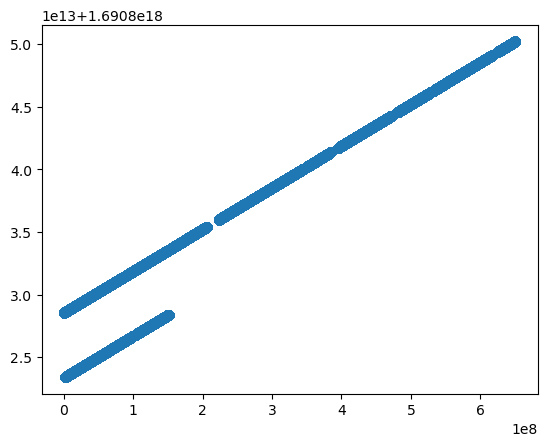

In [177]:
plt.scatter(sample_count[::10],time_seconds[::10])

In [180]:
sample = [1,2,1,2]
sample_all = [1,2,3,4,1,2]
np.argwhere(np.isin(sample_all, sample)).ravel()

array([0, 1, 4, 5])

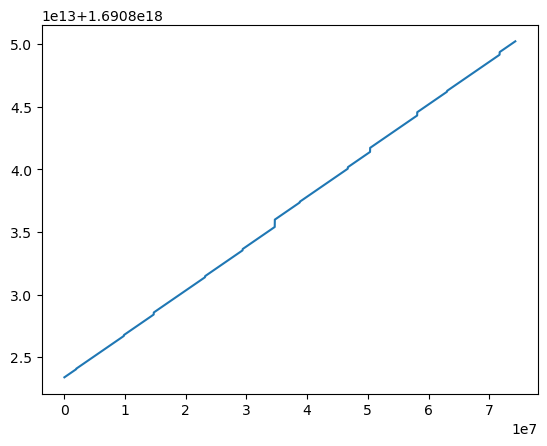

In [176]:
plt.plot(time_seconds[::10])

In [ ]:
plt.plot(time_seconds)

In [171]:
notnan_ind=np.argwhere(~np.isnan(trodes_sample_time)).ravel()
xy,ind1,ind2=np.intersect1d(trodes_sample_time[notnan_ind],sample_count,return_indices=True)
#assert np.sum(~nan_ind)==len(ind2)
translated_sys_time=np.zeros_like(trodes_sample_time)+np.nan
translated_sys_time[notnan_ind[ind1]]=time_seconds[ind2]

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

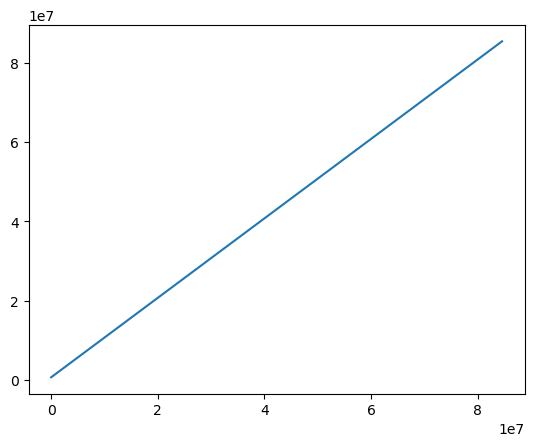

In [163]:
plt.plot(data_day['04_Seq2Session2']['timestamps']['data'])

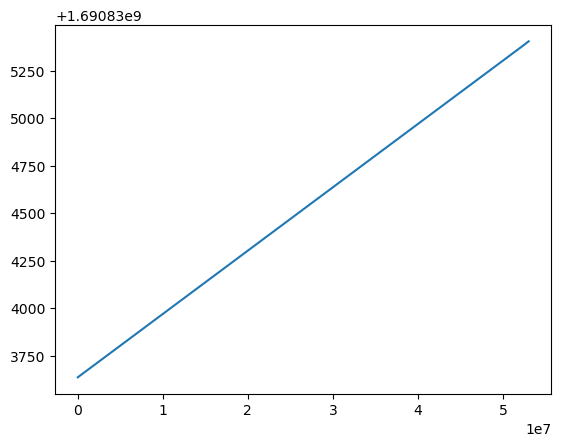

In [168]:
plt.plot(data_day['06_Seq2Session3']['timestamps']['unix'])

In [31]:
data_day['04_Seq2Session2']['timestamps']['unix'][0]

1690828571.4892557

In [32]:
data_day['04_Seq2Session2']['timestamps']['unix'][-1]

1690831391.4323785

### 2. Basic testing

In [116]:
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta
from spyglass.shijiegu.helpers import mergeIntervals,interpolate_to_new_time

In [96]:
# session information
session_interval, position_interval = runSessionNames(nwb_copy_file_name)
session_name = session_interval[0]
pos_name = position_interval[0]

In [99]:
# position
key = {"nwb_file_name": nwb_copy_file_name,"interval_list_name":pos_name}
position_info = (IntervalPositionInfo() & {'nwb_file_name': nwb_copy_file_name,
                'interval_list_name': pos_name,
                "position_info_param_name": "default",
                                          }).fetch1_dataframe()

[2025-12-15 15:19:20,745][WARNING]: Skipped checksum for file with hash: 67f67a4d-2f48-0841-44a7-9f6e498af76a, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_CLPY31LARI.nwb
[2025-12-15 15:19:20,756][WARNING]: Skipped checksum for file with hash: 67f67a4d-2f48-0841-44a7-9f6e498af76a, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_CLPY31LARI.nwb
[2025-12-15 15:19:20,764][WARNING]: Skipped checksum for file with hash: 67f67a4d-2f48-0841-44a7-9f6e498af76a, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_CLPY31LARI.nwb
[2025-12-15 15:19:20,770][WARNING]: Skipped checksum for file with hash: 67f67a4d-2f48-0841-44a7-9f6e498af76a, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_CLPY31LARI.nwb


In [102]:
# trials of interest
q = {"nwb_file_name": nwb_copy_file_name,
     "epoch":int(session_name[:2]),
     "proportion":str(0.1),
     "delta_t_minus":5,
     "delta_t_plus":5}

log_df = ChangeofMindTheta().fetch1_dataframe(q)

change_of_mind_trials = log_df[log_df.change_of_mind].index
print(f"Change of mind trials are: {change_of_mind_trials}")

Change of mind trials are: Index([28, 47, 53, 73, 78], dtype='int64')


### subset of trials

In [120]:
trial1 = 35
trial2 = 37
(t0,t1) = (log_df.loc[trial1].timestamp_H, 
           log_df.loc[trial2].timestamp_O)
extracted_data = extract_gyro_data_in_interval(data_day[session_name], (t0, t1))
gyro_time_trial = extracted_data["timestamps"]

In [121]:
position_info_upsample = interpolate_to_new_time(position_info, gyro_time_trial)
position_info_t = np.array( position_info_upsample.loc[position_info_upsample.head_speed <= 4].index )
low_speed_t = np.isin(gyro_time_trial, position_info_t)

#### (1) Scale as if all chanels are accelerameter

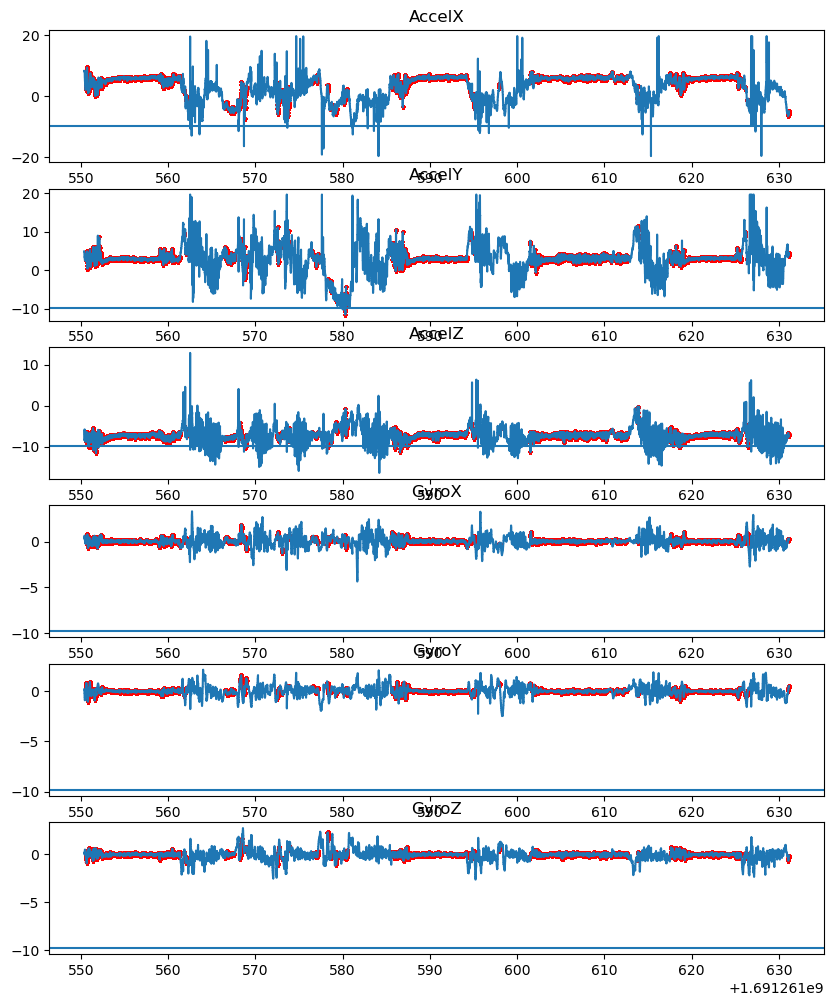

In [125]:
SCALE_FACTOR = 0.000061 * 9.80665 # SCALE_FACTOR for acceleration
fig, axes = plt.subplots(6,1,figsize = (10,12))

t = gyro_time_trial

ind = 0
for data_name in ["AccelX", "AccelY", "AccelZ", "GyroX", "GyroY", "GyroZ"]:
    data_X = extracted_data[data_name].astype("float64")
    axes[ind].plot(t, data_X * SCALE_FACTOR, label = data_name) 
    axes[ind].scatter(t[low_speed_t], data_X[low_speed_t] * SCALE_FACTOR,
                    marker = '*', color = 'r', label = "immobility", s = 3)
    
    axes[ind].set_title(data_name)
    axes[ind].axhline(-9.8)
    ind += 1

#### (2) Scale as if all chanels are gyroscope

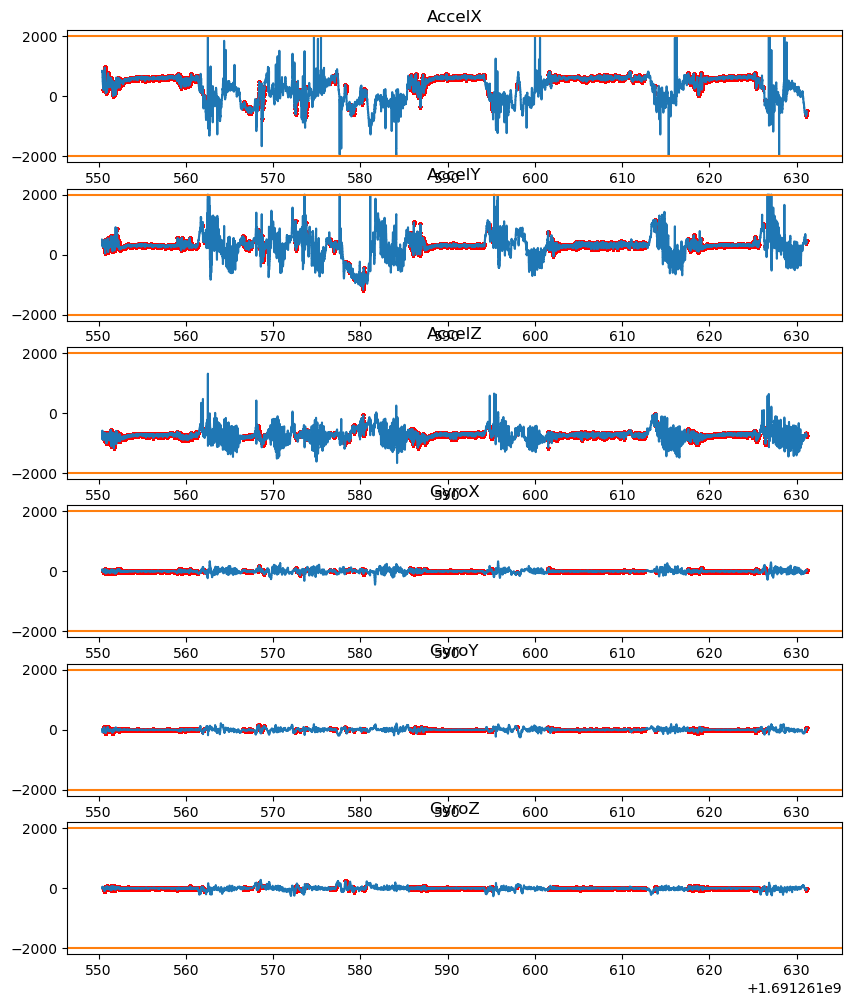

In [128]:
SCALE_FACTOR = 0.061

fig, axes = plt.subplots(6,1,figsize = (10,12))

t = gyro_time_trial

ind = 0
for data_name in ["AccelX", "AccelY", "AccelZ", "GyroX", "GyroY", "GyroZ"]:
    data_X = extracted_data[data_name].astype("float64")
    axes[ind].plot(t, data_X * SCALE_FACTOR, label = data_name) 
    axes[ind].scatter(t[low_speed_t], data_X[low_speed_t] * SCALE_FACTOR,
                    marker = '*', color = 'r', label = "immobility", s = 3)
    
    axes[ind].set_title(data_name)
    axes[ind].axhline(2000, color = 'C1')
    axes[ind].axhline(-2000, color = 'C1')
    ind += 1

### run Trodes tracking

In [137]:
trial1 = 35
trial2 = 37
(t0,t1) = (log_df.loc[trial1].timestamp_H, 
           log_df.loc[trial2].timestamp_O)
extracted_imu_data = extract_gyro_data_in_interval(data_day[session_name], (t0, t1))
extracted_pos_data, table_original, meters_per_pixel = extract_position_data_in_interval(
    nwb_copy_file_name, (t0, t1), pos_name)

imu_path = f'/cumulus/shijie/gyro/imu_{nwb_file_name}_{session_name}_trial{trial1}.parquet'  # the path to write imu data to
pos_path = f'/cumulus/shijie/gyro/position_{nwb_file_name}_{session_name}_trial{trial1}.parquet' # the path to write pos data to

packed_data = prepare_data_for_tracking(
    extracted_imu_data, extracted_pos_data, imu_path, pos_path, meters_per_pixel)


[2025-12-15 16:33:28,401][WARNING]: Skipped checksum for file with hash: 937cfe06-f973-2d35-fdc4-50d27a10a1ba, and path: /stelmo/nwb/raw/julio20230805_.nwb
[2025-12-15 16:33:28,418][WARNING]: Skipped checksum for file with hash: 937cfe06-f973-2d35-fdc4-50d27a10a1ba, and path: /stelmo/nwb/raw/julio20230805_.nwb
[2025-12-15 16:33:28,452][WARNING]: Skipped checksum for file with hash: 937cfe06-f973-2d35-fdc4-50d27a10a1ba, and path: /stelmo/nwb/raw/julio20230805_.nwb
[2025-12-15 16:33:28,469][WARNING]: Skipped checksum for file with hash: 937cfe06-f973-2d35-fdc4-50d27a10a1ba, and path: /stelmo/nwb/raw/julio20230805_.nwb


LOADING ARTHUR SESSION



Raw data:
  Position: 1,891 frames
  IMU: 2,422,568 samples (with sample-and-hold)

Sample-and-hold removal:
  Unique samples: 8,416
  Repeat factor: 287.9×

Sampling rates:
  IMU: 100.0 Hz
  Camera: 23.4 Hz

Duration:
  IMU: 80.8 s (1.3 min)
  Camera: 80.7 s (1.3 min)
  Time overlap: 80.7 s

Unit conversions (IMU mode: 2d):
  Gyro Z: [-271.4, 275.7] deg/s
  Accel X: [-19.60, 19.58] m/s²
  Accel Y: [-11.50, 19.58] m/s²
  LED separation: 6.32 cm
  Arena: 1.28 × 1.77 m

✓ Data ready for trodestrack



In [33]:
inferred_position_x, inferred_position_y, inferred_heading, result = run_trodes_tracking(packed_data)

NameError: name 'packed_data' is not defined

Text(0.5, 1.0, 'Gyro z')

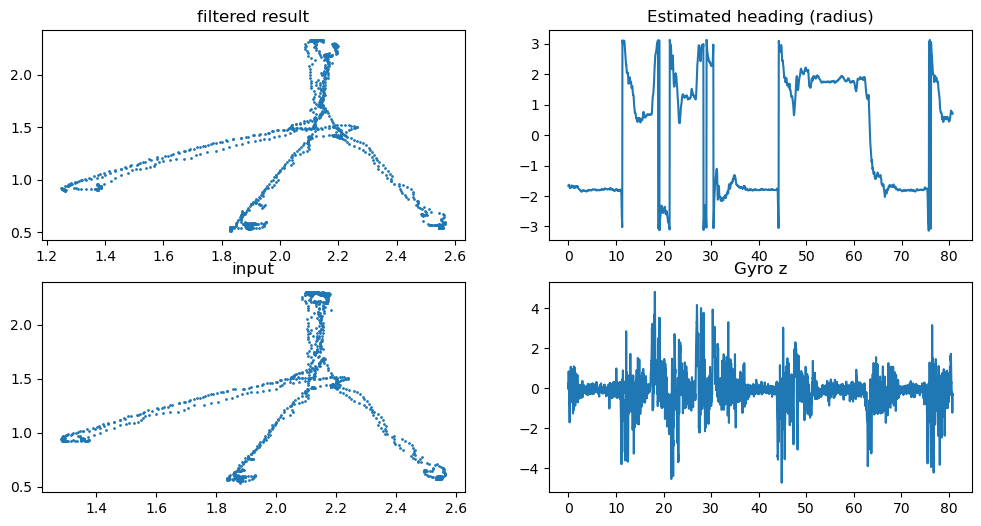

In [140]:
fig, axes = plt.subplots(2,2, figsize = (12,6))
axes[0,0].set_title("filtered result")
axes[0,0].scatter(inferred_position_x, inferred_position_y,s = 1)

axes[0,1].plot(packed_data.t_cam, inferred_heading)
axes[0,1].set_title("Estimated heading (radius)")

axes[1,0].scatter(packed_data.Z_cam_led1[:,0], packed_data.Z_cam_led1[:,1],s = 1)
axes[1,0].set_title("input")

axes[1,1].plot(packed_data.t_imu, packed_data.U_imu[:,0])
axes[1,1].set_title("Gyro z")

### Make video

In [142]:
from trodestrack.data.visualize_session import create_video_overlay
from trodestrack.data.visualize_filter_overlay_fast import create_filter_overlay_video_fast

from trodestrack.data.load_arthur_session import load_video_frame
from spyglass.shijiegu.video import load_video_and_timestamps, make_mp4

In [143]:
cap, timestamps, meters_per_pixel = load_video_and_timestamps(nwb_copy_file_name, session_name)

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/pynwb/behavior.py:48: UserWarning: SpatialSeries 'series_0' has data shape (37468, 6) which is not compliant with NWB 2.5 and greater. The second dimension should have length <= 3 to represent at most x, y, z.
  warnings.warn("SpatialSeries '%s' has data shape %s which is not compliant with NWB 2.5 and greater. "
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/pynwb/behavior.py:48: UserWarning: SpatialSeries 'series_1' has data shape (57607, 6) which is not compliant with NWB 2.5 and greater. The second dimension should have length <= 3 to represent at most x, y, z.
  warnings.warn("SpatialSeries '%s' has data shape %s which is not compliant with NWB 2.5 and greater. "
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/pynwb/behavior.py:48: UserWarning: SpatialSeries 'series_2' has data shape (178134, 6) which is not compliant with NWB 2.5 and greater. The second dimension should ha

In [149]:
#outputName = f'/cumulus/shijie/gyro/position_{nwb_file_name}_{session_name}_trial{trialID}'
outputName = f'position_{nwb_file_name}_{session_name}_trial{trial1}'
make_mp4(cap, timestamps, t0, t1, outputName)

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


'position_julio20230805.nwb_02_Seq2Session1_trial35_rawposition.mp4'

In [150]:
create_video_overlay(
    video_path = outputName + '_rawposition.mp4',
    data = packed_data,
    imu_mode = "2d",
    position_df = extracted_pos_data.to_pandas(),
    output_path = "overlay_3DIMU.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0,
    gyro_ylim=(-200, 200),    # deg/s
    accel_ylim=(-15, 15)      # m/s²
)

CREATING VIDEO VISUALIZATION

Input video: position_julio20230805.nwb_02_Seq2Session1_trial35_rawposition.mp4
  Resolution: 1456×1088
  Frame rate: 23.0 fps
  Duration: 82.2 s

Output: overlay_3DIMU.mp4
  Start time: 0.0 s
  Duration: 80.8 s
  Output fps: 25.0

  Adjusted duration to 80.7s

Generating 2017 frames...

✓ Video saved to: overlay_3DIMU.mp4


In [153]:
process_noise_heading = 0.02 #0.1
process_noise_pos =  0.02 #0.005 #0.02
process_noise_gyro_bias = 2e-6 #0.9
measurement_noise_pos = 0.005**2 #0.4**2
measurement_noise_heading = 0.05**2 #0.9**2

create_filter_overlay_video_fast(
    video_path = outputName + '_rawposition.mp4',
    data = packed_data,
    filter_result = result,
    t_filter = packed_data.t_cam,
    position_df = extracted_pos_data.to_pandas(),
    output_path = f"filter_{nwb_file_name}_{session_name}_gyrobias{np.round(process_noise_gyro_bias,4)}_posprocessnoise{np.round(process_noise_pos,4)}_headingprocessnoise{np.round(process_noise_heading,4)}_posnoise{np.round(measurement_noise_pos,4)}_headnoise{np.round(measurement_noise_heading,4)}.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0
)

FAST FILTER OVERLAY VIDEO

Input: position_julio20230805.nwb_02_Seq2Session1_trial35_rawposition.mp4
  Resolution: 1456×1088
  Frame rate: 23.0 fps

Output: filter_julio20230805.nwb_02_Seq2Session1_gyrobias0.0_posprocessnoise0.02_headingprocessnoise0.02_posnoise0.0_headnoise0.0025.mp4
  Start: 0.0s, Duration: 80.8s
  Output fps: 25.0

Generating 2018 frames...
  Progress: 0/2018 frames (0.0%)
  Progress: 30/2018 frames (1.5%)
  Progress: 60/2018 frames (3.0%)
  Progress: 90/2018 frames (4.5%)
  Progress: 120/2018 frames (5.9%)
  Progress: 150/2018 frames (7.4%)
  Progress: 180/2018 frames (8.9%)
  Progress: 210/2018 frames (10.4%)
  Progress: 240/2018 frames (11.9%)
  Progress: 270/2018 frames (13.4%)
  Progress: 300/2018 frames (14.9%)
  Progress: 330/2018 frames (16.4%)
  Progress: 360/2018 frames (17.8%)
  Progress: 390/2018 frames (19.3%)
  Progress: 420/2018 frames (20.8%)
  Progress: 450/2018 frames (22.3%)
  Progress: 480/2018 frames (23.8%)
  Progress: 510/2018 frames (25.3%)
 